# Algoritmos de regresión

Dado un conjunto de datos:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}
$$

donde:
- $x_i \in \mathbb{R}^d$ son las características
- $y_i \in \mathbb{R}$ es la variable objetivo

El objetivo es encontrar una función:

$$
f(x; \theta)
$$

que minimice el error esperado.

En la práctica, se minimiza el error empírico:

$$
\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f(x_i))
$$

Usualmente se emplea el error cuadrático medio (MSE):

$$
L(y, \hat{y}) = (y - \hat{y})^2
$$

$$
\Rightarrow \min_{\theta} \frac{1}{n} \sum_{i=1}^{n} (y_i - f(x_i))^2
$$

Lo que conduce a una solución cerrada (en forma matricial):

$$
\hat{w} = (X^T X)^{-1} X^T y
$$

donde:
- $X$ es la matriz de diseño
- $y$ es el vector de salidas


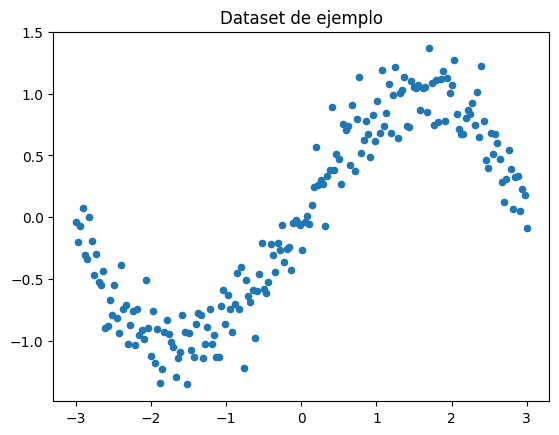

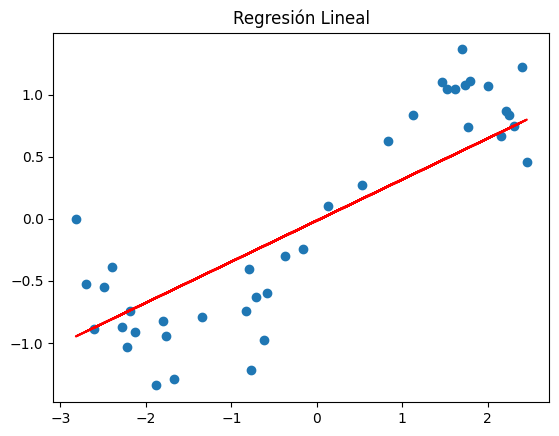

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Generamos dataset no lineal
X = np.linspace(-3, 3, 200).reshape(-1,1)
y = np.sin(X).ravel() + np.random.normal(0, 0.2, 200)

plt.scatter(X, y, s=20)
plt.title("Dataset de ejemplo")
plt.show()

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred_lr, color='red')
plt.title("Regresión Lineal")
plt.show()

## Regresión K-NN

En este caso no se aprende un modelo explícito. Para un nuevo punto $x$:

1. Se encuentran los $k$ vecinos más cercanos:
$$
\mathcal{N}_k(x)
$$

2. Se predice como el promedio:

$$
f(x) = \frac{1}{k} \sum_{x_i \in \mathcal{N}_k(x)} y_i
$$

### Variante ponderada

$$
f(x) = \frac{\sum_{i} w_i y_i}{\sum_i w_i}, \quad w_i = \frac{1}{d(x, x_i)}
$$


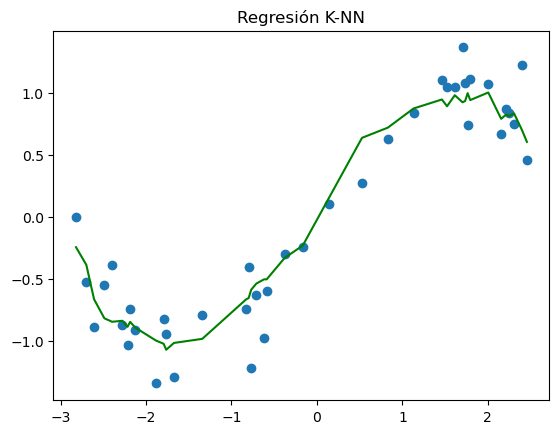

In [2]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train, y_train)

y_pred_knn = model_knn.predict(X_test)

# Visualización ordenada
idx = np.argsort(X_test[:,0])

plt.scatter(X_test, y_test)
plt.plot(X_test[idx], y_pred_knn[idx], color='green')
plt.title("Regresión K-NN")
plt.show()

## ε-SVR

La regresión ε-SVR busca una función de la forma:

$$
f(x) = w^T \phi(x) + b
$$

donde $\phi(x)$ es un mapeo a un espacio de mayor dimensión.

Para esto, se define un "tubo" de insensibilidad con radio ε que se define matemáticamente mediante:

$$
\min_{w,b} \frac{1}{2} \|w\|^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)
$$

sujeto a:

$$
y_i - f(x_i) \leq \varepsilon + \xi_i
$$

$$
f(x_i) - y_i \leq \varepsilon + \xi_i^*
$$

$$
\xi_i, \xi_i^* \geq 0
$$

donde:

- $\varepsilon$: zona de tolerancia (tubo)
- $C$: penalización de errores
- $\|w\|^2$: controla complejidad


Igual que en las SVM, reemplazar los productos punto por una función kernel permite trabajar sin calcular explícitamente $\phi(x)$:

$$
K(x_i, x_j) = \phi(x_i)^T \phi(x_j)
$$

Ejemplo: RBF

$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
$$

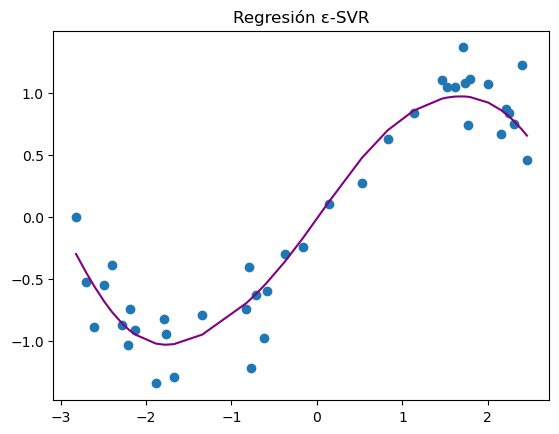

In [3]:
from sklearn.svm import SVR

model_svr = SVR(kernel='rbf', C=10, epsilon=0.1)
model_svr.fit(X_train, y_train)

y_pred_svr = model_svr.predict(X_test)

idx = np.argsort(X_test[:,0])

plt.scatter(X_test, y_test)
plt.plot(X_test[idx], y_pred_svr[idx], color='purple')
plt.title("Regresión ε-SVR")
plt.show()

## Regresión con ANN

En problemas de regresión, la elección de la función de activación depende de la **capa de salida**.

A diferencia de clasificación, en regresión se desea predecir un valor continuo:

$$
\hat{y} \in \mathbb{R}
$$

Por lo tanto, la función de activación en la salida debe ser lineal (identidad)

$$
f(x) = x
$$

Esto permite que la red produzca cualquier valor real (positivo o negativo), sin restricciones.

En las capas internas sí se utilizan funciones no lineales, típicamente:

- ReLU
- Tanh
- (menos común hoy) Sigmoide

Estas permiten modelar relaciones no lineales complejas:

$$
h = \sigma(Wx + b)
$$

Función de pérdida: error cuadrático medio (MSE)

$$
L = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$


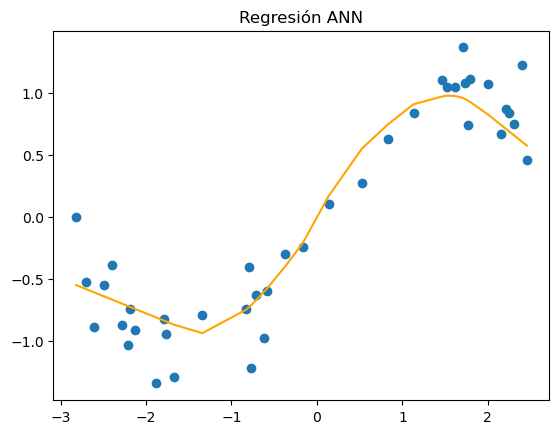

In [4]:
from sklearn.neural_network import MLPRegressor

model_ann = MLPRegressor(hidden_layer_sizes=(50,50),
                         activation='relu',
                         max_iter=2000)

model_ann.fit(X_train, y_train)

y_pred_ann = model_ann.predict(X_test)

idx = np.argsort(X_test[:,0])

plt.scatter(X_test, y_test)
plt.plot(X_test[idx], y_pred_ann[idx], color='orange')
plt.title("Regresión ANN")
plt.show()